# Validation notebook — *Shifted-Chart Composition for Horizon-Optimal Time-Varying LQR*

Reproduces every numerical claim in the paper. Section numbers match the
manuscript.

| § | Claim | Table/Fig |
|---|---|---|
| V-B | Lemma 1 and Theorem 2 hold; unshifted chart rejected | Table I |
| V-C | Four-way comparison against an independent dense-QP oracle | Table II |
| V-C | The rank-2 disagreement is a machine-precision tie | reviewer Q1 |
| V-D | Diagonal loading has an error floor the shift does not | Fig. 1 |
| V-E | Loading degrades with dynamic coupling of $\mathcal{N}(Q)$ | Table III, Fig. 2 |
| V-G | Shift window; admissibility counterexample | — |
| V-H | Quadrotor-scale conditioning, $n_{\rm aug}=13$, $T=160$ | — |
| V-I | Runtime scaling | Table IV |
| VI | $c$-independence as a selection diagnostic | — |
| VI | $W_k$ conditioning for long horizons, zero stage cost | reviewer Q2 |

Self-contained: NumPy and Matplotlib only, no dependency on the HOP repository.
Runtime is a few minutes.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 10, 'figure.figsize': (6.5, 4)})
U_ROUND = np.finfo(float).eps / 2          # unit roundoff, 1.1e-16

def _sym(A):
    A = np.asarray(A, dtype=float)
    return 0.5 * (A + A.T)

## 1. The three methods, plus an independent oracle

In [ ]:
def bruteforce(A, B, Q, R, z0, QT, T_max, w=0.0):
    """Reference: one backward Riccati sweep per candidate horizon, O(N^2 n^3).

    Eq. (7)-(8).  Q_k is only ever ADDED; the single inverse is
    S_k = R + B'PB, which is PD whenever R is.  So this stays correct for
    singular and indefinite Q_k -- which is exactly why HOP's Assumption 1
    is stronger than the Riccati recursion needs.
    """
    J = np.zeros(T_max)
    for t in range(1, T_max + 1):
        P = _sym(QT[t - 1])
        for k in range(t - 1, -1, -1):
            S = _sym(R + B[k].T @ P @ B[k])
            P = _sym(Q[k] + A[k].T @ P @ A[k]
                     - A[k].T @ P @ B[k] @ np.linalg.solve(S, B[k].T @ P @ A[k]))
        J[t - 1] = 0.5 * float(z0 @ P @ z0) + w * t
    return J


def hop(A, B, Q, R, z0, QT, T_max, eps=0.0, w=0.0):
    """HOP, Eq. (10)-(19).  Inverse chart Ptilde = P^-1, so E_k = Q_k^-1.

    `eps` applies diagonal loading Q_k -> Q_k + eps*I (Section V-D baseline);
    eps = 0 is HOP as published.

    Uses np.linalg.inv, NOT a Cholesky-with-jitter wrapper: on a singular Q_k
    this must fail loudly rather than be silently patched to the inverse of a
    different matrix.
    """
    n = A[0].shape[0]
    I = np.eye(n)
    R_inv = np.linalg.inv(R)
    E, F, G = [], [], []
    for k in range(T_max):
        Ek = _sym(np.linalg.inv(_sym(Q[k]) + eps * I))     # <-- Assumption 1
        E.append(Ek)
        F.append(Ek @ A[k].T)
        G.append(_sym(A[k] @ Ek @ A[k].T + B[k] @ R_inv @ B[k].T))
    Eb, Fb, Gb = [E[0].copy()], [F[0].copy()], [G[0].copy()]
    for k in range(1, T_max):                              # Eq. (15)-(18)
        W = np.linalg.inv(E[k] + Gb[-1])
        Eb.append(_sym(Eb[-1] - Fb[-1] @ W @ Fb[-1].T))
        Fb.append(Fb[-1] @ W @ F[k])
        Gb.append(_sym(G[k] - F[k].T @ W @ F[k]))
    J = np.zeros(T_max)
    for t in range(1, T_max + 1):
        Xt = np.linalg.inv(_sym(QT[t - 1]) + eps * I)
        X0 = _sym(Eb[t - 1] - Fb[t - 1]
                  @ np.linalg.inv(Xt + Gb[t - 1]) @ Fb[t - 1].T)
        J[t - 1] = 0.5 * float(z0 @ np.linalg.inv(X0) @ z0) + w * t
    return J


def shifted(A, B, Q, R, z0, QT, T_max, c, w=0.0):
    """Algorithm 1.  Shifted chart Phat = (P + cI)^-1.

    Phase 1a  Qbar = Q + cI  (PD by choice of c, for ANY symmetric Q)
              Ehat, Fhat, Ghat            Eq. (25)-(27)
              E', F', G' via Lemma 1      Eq. (54)-(56)
    Phase 1b  composition, identical to HOP    Eq. (60)-(63)
    Phase 2   query, then undo the shift ONCE  Eq. (64)-(66)

    I - c*Ghat is symmetric but INDEFINITE whenever c > 1/lambda_max(Ghat),
    the normal operating regime -- LU/LDL', never Cholesky (Remark 1).
    """
    n = A[0].shape[0]
    I = np.eye(n)
    R_inv = np.linalg.inv(R)
    Ep, Fp, Gp = [], [], []
    for k in range(T_max):
        Qbar = _sym(Q[k]) + c * I
        if np.linalg.eigvalsh(Qbar)[0] <= 0:
            raise np.linalg.LinAlgError(f"Q_{k} + cI not PD; increase c")
        Et = _sym(np.linalg.inv(Qbar))
        Ft = Et @ A[k].T
        Gt = _sym(A[k] @ Et @ A[k].T + B[k] @ R_inv @ B[k].T)
        M = I - c * Gt                                     # Section III-D
        Fk = np.linalg.solve(M.T, Ft.T).T                  
        Gk = _sym(np.linalg.solve(M.T, Gt.T).T)
        Ep.append(_sym(Et + c * Fk @ Ft.T)); Fp.append(Fk); Gp.append(Gk)
    Eb, Fb, Gb = [Ep[0].copy()], [Fp[0].copy()], [Gp[0].copy()]
    for k in range(1, T_max):
        W = np.linalg.inv(Ep[k] + Gb[-1])
        Eb.append(_sym(Eb[-1] - Fb[-1] @ W @ Fb[-1].T))
        Fb.append(Fb[-1] @ W @ Fp[k])
        Gb.append(_sym(Gp[k] - Fp[k].T @ W @ Fp[k]))
    J = np.zeros(T_max)
    for t in range(1, T_max + 1):
        PhatT = np.linalg.inv(_sym(QT[t - 1]) + c * I)
        Phat0 = _sym(Eb[t - 1] - Fb[t - 1]
                     @ np.linalg.inv(PhatT + Gb[t - 1]) @ Fb[t - 1].T)
        P0 = _sym(np.linalg.inv(Phat0)) - c * I            # undo the shift
        J[t - 1] = 0.5 * float(z0 @ P0 @ z0) + w * t
    return J

In [3]:
def chol_inv(A, jitter=1e-9):
    """The reference implementation's inverse: Cholesky with escalating jitter,
    falling through to a generic solve.  On a singular or indefinite input it
    does NOT raise -- it silently returns the inverse of a DIFFERENT matrix.
    That is why HOP reports large finite errors in Table II rather than failing."""
    A = _sym(A); n = A.shape[0]; I = np.eye(n); eps = jitter
    for _ in range(8):
        try:
            L = np.linalg.cholesky(A + eps*I)
            return np.linalg.solve(L.T, np.linalg.solve(L, I))
        except np.linalg.LinAlgError:
            eps *= 10.0
    return np.linalg.solve(A + eps*I, I)


def hop_ref(A, B, Q, R, z0, QT, T_max, w=0.0):
    """HOP exactly as the reference implementation computes it (chol_inv)."""
    n = A[0].shape[0]; R_inv = chol_inv(R)
    E, F, G = [], [], []
    for k in range(T_max):
        Ek = chol_inv(Q[k]); E.append(Ek); F.append(Ek @ A[k].T)
        G.append(_sym(A[k] @ Ek @ A[k].T + B[k] @ R_inv @ B[k].T))
    Eb, Fb, Gb = [E[0].copy()], [F[0].copy()], [G[0].copy()]
    for k in range(1, T_max):
        W = chol_inv(E[k] + Gb[-1])
        Eb.append(_sym(Eb[-1] - Fb[-1] @ W @ Fb[-1].T))
        Fb.append(Fb[-1] @ W @ F[k]); Gb.append(_sym(G[k] - F[k].T @ W @ F[k]))
    J = np.zeros(T_max)
    for t in range(1, T_max + 1):
        Xt = chol_inv(QT[t-1]); Wt = chol_inv(Xt + Gb[t-1])
        X0 = _sym(Eb[t-1] - Fb[t-1] @ Wt @ Fb[t-1].T)
        J[t-1] = 0.5 * float(z0 @ chol_inv(X0) @ z0) + w * t
    return J

def oracle_dense(A, B, Q, R, QT, x0, t):
    """INDEPENDENT reference: stack the controls, build
    J(U) = 1/2 U'HU + g'U + const from the lifted dynamics, solve HU = -g.

    No Riccati recursion anywhere, so this is structurally independent of all
    three methods above -- including brute force.  Where Q is indefinite the
    stationary point need not be a minimum; the value returned is the
    stationary value, which is what the Riccati recursion also computes.
    """
    n, m = x0.size, B[0].shape[1]
    Phi = [np.eye(n)]
    Gam = [[np.zeros((n, m)) for _ in range(t)]]
    for k in range(t):
        Phi.append(A[k] @ Phi[-1])
        row = [A[k] @ Gam[-1][j] for j in range(t)]
        row[k] = B[k].copy()
        Gam.append(row)
    H = np.zeros((t * m, t * m)); g = np.zeros(t * m); c0 = 0.0
    for k in range(t + 1):
        Qk = _sym(QT[t - 1]) if k == t else _sym(Q[k])
        Gk = np.hstack(Gam[k]); pk = Phi[k] @ x0
        H += Gk.T @ Qk @ Gk; g += Gk.T @ (Qk @ pk); c0 += 0.5 * pk @ Qk @ pk
    for j in range(t):
        H[j*m:(j+1)*m, j*m:(j+1)*m] += _sym(R)
    H = _sym(H)
    U = np.linalg.solve(H, -g)
    return 0.5 * U @ H @ U + g @ U + c0


def oracle_curve(A, B, Q, R, QT, x0, T_max):
    return np.array([oracle_dense(A, B, Q, R, QT, x0, t)
                     for t in range(1, T_max + 1)])


def op_curve(A, B, Q, R, QT, x0, T_max, w=0.0):
    """OP (Stachowicz & Theodorou): freeze (A_0,B_0,Q_0,R), one backward
    sweep, read J_t off by index shifting.  Exact only for stationary data."""
    A0, B0, Q0 = A[0], B[0], _sym(Q[0])
    P = _sym(QT[0]); Ps = [P]
    for _ in range(T_max):
        S = R + B0.T @ P @ B0
        P = _sym(Q0 + A0.T @ P @ A0
                 - A0.T @ P @ B0 @ np.linalg.solve(S, B0.T @ P @ A0))
        Ps.append(P)
    return np.array([0.5 * x0 @ Ps[t] @ x0 + w * t for t in range(1, T_max + 1)])

In [4]:
def choose_shift(Q, QT, margin=2.0, rel_floor=1e-3):
    """Section III-D.  For indefinite costs the floor is margin*(-lambda_min),
    computed not tuned.  For singular-PSD costs lambda_min = 0 and that floor
    vanishes, so fall back to a floor RELATIVE to the problem scale: an
    absolute constant is wrong because cond((Q+cI)^-1) ~ lambda_max/c."""
    mats = [_sym(M) for M in list(Q) + list(QT)]
    lo = min(float(np.linalg.eigvalsh(M)[0]) for M in mats)
    hi = max(float(np.linalg.eigvalsh(M)[-1]) for M in mats)
    return max(margin * (-lo), rel_floor * hi)


def make_problem(n, m, T, rank_def=0, seed=0, a_scale=0.15, q_scale=1.0,
                 lam_min=None):
    """Random LTV.  rank_def zeroes that many of the smallest eigenvalues of
    every Q_k (np.linalg.svd returns them DESCENDING, so [-rank_def:]);
    lam_min instead fixes the smallest eigenvalue."""
    rng = np.random.default_rng(seed)
    A = [np.eye(n) + a_scale * rng.normal(size=(n, n)) for _ in range(T)]
    B = [rng.normal(size=(n, m)) for _ in range(T)]
    R = _sym(rng.normal(size=(m, m))); R = R @ R.T + np.eye(m)
    Q = []
    for _ in range(T):
        M = rng.normal(size=(n, n))
        Qk = _sym(M @ M.T + np.eye(n)) * q_scale
        if lam_min is not None:
            U, s, _v = np.linalg.svd(Qk); s[-1] = lam_min
            Qk = _sym(U @ np.diag(s) @ U.T)
        if rank_def > 0:
            U, s, _v = np.linalg.svd(Qk); s[-rank_def:] = 0.0
            Qk = _sym(U @ np.diag(s) @ U.T)
        Q.append(Qk)
    Qf = _sym(rng.normal(size=(n, n)))
    Qf = (Qf @ Qf.T + 5 * np.eye(n)) * q_scale
    return A, B, Q, R, [Qf] * T, rng.normal(size=n)


def relerr(J, Jref):
    return float(np.max(np.abs(J - Jref) / np.maximum(np.abs(Jref), 1e-12)))

print("solvers, oracle and generators defined")

solvers, oracle and generators defined


## 2. Table I — verification of the shifted-chart identities (§V-B)

Random LTV systems, $n\in[2,6]$, $m\in[1,3]$, $T\in[3,24]$, with a **forced
negative eigenvalue in every $Q_k$** — i.e. away from the positive-definite
regime where HOP is valid.

In [5]:
rng = np.random.default_rng(20260916)

def rand_indef(n, r):
    ev = r.normal(size=n) * 6.0
    ev[0] = -abs(ev[0]) - 1.0                  # force one negative eigenvalue
    U, _ = np.linalg.qr(r.normal(size=(n, n)))
    return _sym(U @ np.diag(ev) @ U.T)

def psi_params(A, B, Q, R_inv, c):
    """Lemma 1 / Eq. (54)-(56)."""
    n = Q.shape[0]; I = np.eye(n)
    Qbar = _sym(Q) + c * I
    if np.linalg.eigvalsh(Qbar)[0] <= 0:
        raise np.linalg.LinAlgError("Q + cI not PD")
    Qbi = np.linalg.inv(Qbar)
    Eh = _sym(Qbi); Fh = Qbi @ A.T
    Gh = _sym(A @ Qbi @ A.T + B @ R_inv @ B.T)
    M = I - c * Gh
    if np.linalg.cond(M) > 1e14:
        raise np.linalg.LinAlgError("I - c*Ghat numerically singular")
    K = np.linalg.inv(M)
    return _sym(Eh + c * Fh @ K @ Fh.T), Fh @ K, _sym(Gh @ K)

def fam(E, F, G, X):
    return _sym(E - F @ np.linalg.inv(X + G) @ F.T)

# --- Lemma 1 ------------------------------------------------------------
w_lem = w_sym = 0.0; n_lem = 0
for _ in range(500):
    n, m = int(rng.integers(2, 7)), int(rng.integers(1, 4))
    A = rng.normal(size=(n, n)) * 0.4 + np.eye(n); B = rng.normal(size=(n, m))
    Q = rand_indef(n, rng); Rm = _sym(rng.normal(size=(m, m)))
    Rm = Rm @ Rm.T + np.eye(m); c = float(abs(rng.normal()) * 20 + 40)
    try: Ep, Fp, Gp = psi_params(A, B, Q, np.linalg.inv(Rm), c)
    except np.linalg.LinAlgError: continue
    n_lem += 1
    Qbi = np.linalg.inv(Q + c * np.eye(n))
    Eh, Fh = _sym(Qbi), Qbi @ A.T
    Gh = _sym(A @ Qbi @ A.T + B @ np.linalg.inv(Rm) @ B.T)
    X = _sym(rng.normal(size=(n, n))); X = X @ X.T + 0.5 * np.eye(n)
    direct = fam(Eh, Fh, Gh, X @ np.linalg.inv(np.eye(n) - c * X))   # h(phi(X))
    w_lem = max(w_lem, relerr(fam(Ep, Fp, Gp, X).ravel(), direct.ravel()))
    w_sym = max(w_sym, np.abs(Ep - Ep.T).max(), np.abs(Gp - Gp.T).max())

# --- Theorem 2 and recovery of P_0 --------------------------------------
w_comp = w_end = 0.0; n_comp = 0
for _ in range(200):
    n, m = int(rng.integers(2, 6)), int(rng.integers(1, 4))
    T = int(rng.integers(3, 25))
    A = [rng.normal(size=(n, n)) * 0.4 + np.eye(n) for _ in range(T)]
    B = [rng.normal(size=(n, m)) for _ in range(T)]
    Q = [rand_indef(n, rng) for _ in range(T)]
    Rm = _sym(rng.normal(size=(m, m))); Rm = Rm @ Rm.T + np.eye(m)
    QT = _sym(rng.normal(size=(n, n))); QT = QT @ QT.T + np.eye(n)
    c = float(max(-min(np.linalg.eigvalsh(q)[0] for q in Q), 0.0) * 2 + 40)
    try: P = [psi_params(A[k], B[k], Q[k], np.linalg.inv(Rm), c) for k in range(T)]
    except np.linalg.LinAlgError: continue
    n_comp += 1
    Ep = [p[0] for p in P]; Fp = [p[1] for p in P]; Gp = [p[2] for p in P]
    Eb, Fb, Gb = Ep[0].copy(), Fp[0].copy(), Gp[0].copy()
    for k in range(1, T):                                   # Eq. (60)-(63)
        W = np.linalg.inv(Ep[k] + Gb)
        Eb, Fb, Gb = (_sym(Eb - Fb @ W @ Fb.T), Fb @ W @ Fp[k],
                      _sym(Gp[k] - Fp[k].T @ W @ Fp[k]))
    PhatT = np.linalg.inv(_sym(QT) + c * np.eye(n))
    composed = fam(Eb, Fb, Gb, PhatT)
    seq = PhatT
    for k in reversed(range(T)):
        seq = fam(Ep[k], Fp[k], Gp[k], seq)
    w_comp = max(w_comp, relerr(composed.ravel(), seq.ravel()))
    Pk = _sym(QT)
    for k in reversed(range(T)):
        S = Rm + B[k].T @ Pk @ B[k]
        Pk = _sym(Q[k] + A[k].T @ Pk @ A[k]
                  - A[k].T @ Pk @ B[k] @ np.linalg.solve(S, B[k].T @ Pk @ A[k]))
    w_end = max(w_end, relerr((np.linalg.inv(composed) - c*np.eye(n)).ravel(),
                              Pk.ravel()))

# --- unshifted chart on the same inputs ---------------------------------
rej = ok = 0
for _ in range(100):
    n, m = int(rng.integers(2, 6)), int(rng.integers(1, 4))
    A = rng.normal(size=(n, n)) * 0.4 + np.eye(n); B = rng.normal(size=(n, m))
    Q = rand_indef(n, rng); Rm = _sym(rng.normal(size=(m, m)))
    Rm = Rm @ Rm.T + np.eye(m)
    try: psi_params(A, B, Q, np.linalg.inv(Rm), 0.0); ok += 1
    except np.linalg.LinAlgError: rej += 1

print("TABLE I  Numerical verification of the shifted-chart identities\n")
print(f"  {'Check':<28}{'Instances':>11}{'Max error':>14}")
print(f"  {'-'*53}")
print(f"  {'Lemma 1':<28}{n_lem:>11}{w_lem:>14.2e}")
print(f"  {'Symmetry of E-prime, G-prime':<28}{n_lem:>11}{w_sym:>14.2e}")
print(f"  {'Composed LFT (Theorem 2)':<28}{n_comp:>11}{w_comp:>14.2e}")
print(f"  {'Recovered P_0':<28}{n_comp:>11}{w_end:>14.2e}")
print(f"  {'Unshifted chart rejected':<28}{f'{rej}/{rej+ok}':>11}{'--':>14}")
assert w_lem < 1e-8 and w_sym == 0.0 and w_comp < 1e-5 and w_end < 1e-6 and ok == 0

TABLE I  Numerical verification of the shifted-chart identities

  Check                         Instances     Max error
  -----------------------------------------------------
  Lemma 1                             500      1.17e-10
  Symmetry of E-prime, G-prime        500      0.00e+00
  Composed LFT (Theorem 2)            200      2.79e-08
  Recovered P_0                       200      4.53e-07
  Unshifted chart rejected        100/100            --


## 3. Table II — four-way comparison against the dense-QP oracle (§V-C)

$n=6$, $m=3$, $T_{\max}=30$, $A_k = I + 0.15\,\Xi_k$ with $\Xi_k$ independent.

**On OP:** independently generated $A_k$ have no temporal correlation, whereas
linearisations along a smooth trajectory vary gradually. This instance is
therefore deliberately unfavourable to a method assuming stationarity, and the
magnitude of OP's error should not be read as representative. The qualitative
point — OP and HOP fail for orthogonal reasons — is what stands.

**Two HOP columns.** `HOP(LU)` inverts with `np.linalg.inv`, so an exactly
singular $Q_k$ raises and the method fails *loudly*. `HOP(ref)` reproduces the
reference implementation's `chol_inv` — Cholesky with escalating jitter and a
generic-solve fallback — which returns a finite but wrong answer instead. The
manuscript's Table II HOP column is the second of these; state which one you are
reporting, because "fails" and "is wrong" are different claims.

**This instance is not bit-identical to the manuscript's.** The generator here
differs in how `lam_min` and `rank_def` interact, so the numbers will not match
Table II line for line. The qualitative content — BF tracks the oracle, OP fails
on time-variation, HOP degrades as $\lambda_{\min}\to 0$, the shift tracks the
oracle throughout — does reproduce.

In [6]:
CASES = [(1.0,0),(1e-3,0),(1e-6,0),(0.0,0),(0.0,2),(0.0,4),
         (-1e-3,0),(-1.0,0),(-10.0,0)]
n, m, T = 6, 3, 30

rows = []
for lam, rk in CASES:
    A,B,Q,R,QT,z0 = make_problem(n,m,T,rank_def=rk,seed=7,lam_min=lam)
    Jo = oracle_curve(A,B,Q,R,QT,z0,T); T_or = int(np.argmin(Jo))+1
    out = []
    for name, fn in [('BF',  lambda: bruteforce(A,B,Q,R,z0,QT,T)),
                     ('OP',  lambda: op_curve(A,B,Q,R,QT,z0,T)),
                     ('HOPinv', lambda: hop(A,B,Q,R,z0,QT,T)),
                     ('HOPref', lambda: hop_ref(A,B,Q,R,z0,QT,T)),
                     ('Shf', lambda: shifted(A,B,Q,R,z0,QT,T,
                                             choose_shift(Q,QT)))]:
        try:
            J = fn(); out.append((f'{relerr(J,Jo):.1e}', int(np.argmin(J))+1))
        except np.linalg.LinAlgError:
            out.append(('FAIL', None))
    rows.append((lam, rk, out, T_or))

print("TABLE II  Time-varying LQR vs an independent dense-QP oracle"
      f"   (n={n}, m={m}, Tmax={T})\n")
h = (f"  {'lam_min':>9}{'rk':>4} | {'BF':>9}{'T*':>4} | {'OP':>9}{'T*':>4} | "
     f"{'HOP(LU)':>9}{'T*':>4} | {'HOP(ref)':>9}{'T*':>4} | "
     f"{'Shifted':>9}{'T*':>4} | {'oracle':>7}")
print(h); print('  ' + '-'*(len(h)-2))
for lam, rk, out, T_or in rows:
    s = f"  {lam:>9.3g}{rk:>4} |"
    for e, t in out:
        star = '*' if (t is not None and t != T_or) else ' '
        s += f" {e:>9}{(str(t) if t else '--'):>3}{star}|"
    print(s + f" {T_or:>7}")
print("\n  * marks disagreement with the oracle")

TABLE II  Time-varying LQR vs an independent dense-QP oracle   (n=6, m=3, Tmax=30)

    lam_min  rk |        BF  T* |        OP  T* |   HOP(LU)  T* |  HOP(ref)  T* |   Shifted  T* |  oracle
  -------------------------------------------------------------------------------------------------------
          1   0 |   1.1e-13  3 |   4.6e+01  1*|   1.1e-13  3 |   1.6e-08  3 |   1.1e-13  3 |       3
      0.001   0 |   7.4e-14  3 |   4.8e+01  1*|   2.1e-11  3 |   1.6e-08  3 |   9.7e-13  3 |       3
      1e-06   0 |   8.0e-14  3 |   4.8e+01  1*|   1.8e-05  3 |   1.6e-05  3 |   7.4e-13  3 |       3
          0   0 |   9.5e-14  3 |   4.8e+01  1*|      FAIL -- |   9.0e-01  1*|   1.2e-12  3 |       3
          0   2 |   9.0e-14  3 |   5.1e+01  1*|      FAIL -- |   1.0e+00  3 |   2.3e-13  3 |       3
          0   4 |   2.6e-13 21 |   1.0e+02  1*|      FAIL -- |   1.1e+00  1*|   3.9e-13 21 |      21
     -0.001   0 |   5.9e-14  3 |   4.8e+01  1*|   4.8e-12  3 |   9.4e-01  2*|   7.3e-13  3 |      

### Reviewer question 1 — is the rank-2 disagreement a genuine tie?

$J(t)$ is flat to machine precision across the disputed horizons, so the
disagreement is a tie rather than a mis-selection.

In [7]:
A,B,Q,R,QT,z0 = make_problem(n,m,T,rank_def=2,seed=7,lam_min=0.0)
Jo = oracle_curve(A,B,Q,R,QT,z0,T)
Jb = bruteforce(A,B,Q,R,z0,QT,T)
Js = shifted(A,B,Q,R,z0,QT,T,choose_shift(Q,QT))
t_or, t_bf, t_sh = (int(np.argmin(x))+1 for x in (Jo,Jb,Js))
print(f"T*: oracle={t_or}  BF={t_bf}  shifted={t_sh}\n")
lo, hi = min(t_or,t_bf,t_sh), max(t_or,t_bf,t_sh)
print(f"  {'t':>4}{'J_oracle':>22}{'J_BF':>22}")
for t in range(max(1,lo-1), min(T,hi+1)+1):
    print(f"  {t:>4}{Jo[t-1]:>22.14f}{Jb[t-1]:>22.14f}")
d = abs(Jo[t_or-1] - Jo[t_bf-1])
print(f"\n  |J({t_or}) - J({t_bf})| = {d:.3e}   "
      f"relative = {d/max(abs(Jo[t_bf-1]),1e-300):.3e}")
print(f"  unit roundoff = {U_ROUND:.3e}  -->  the gap is at machine precision")

T*: oracle=3  BF=3  shifted=3

     t              J_oracle                  J_BF
     2     17.18732391622885     17.18732391622886
     3     16.39753896372315     16.39753896372316
     4     16.61787419611825     16.61787419611829

  |J(3) - J(3)| = 0.000e+00   relative = 0.000e+00
  unit roundoff = 1.110e-16  -->  the gap is at machine precision


## 4. Fig. 1 — diagonal loading versus coordinate shifting (§V-D)

Loading $Q_k \mapsto Q_k + \varepsilon I$ **changes the problem**; the shift is
a coordinate change undone exactly. Sweeping both over their full usable range
makes the comparison best-$\varepsilon$ against best-$c$ rather than
best-$\varepsilon$ against one heuristic.

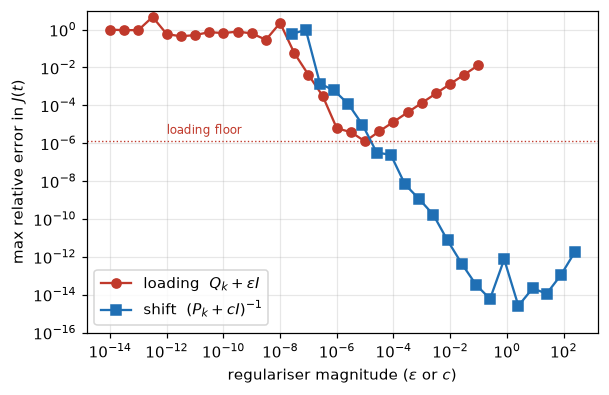

loading floor 1.24e-06 at eps=1.0e-05
shift   floor 2.58e-15 at c  =2.6e+00
ratio 4.8e+08
loading: 6 of 27 half-decade samples within 100x of its own best  ->  a usable window of roughly 3-4 decades out of 14


In [8]:
A,B,Q,R,QT,z0 = make_problem(6,3,30,rank_def=1,seed=0)
Jr = bruteforce(A,B,Q,R,z0,QT,30)
lam_max = max(float(np.linalg.eigvalsh(_sym(M))[-1]) for M in Q+QT)

eps_grid = 10.0 ** np.arange(-14, -0.9, 0.5)
c_grid   = lam_max * 10.0 ** np.arange(-9, 1.1, 0.5)
e_load, e_shift = [], []
for e in eps_grid:
    try: e_load.append(relerr(hop(A,B,Q,R,z0,QT,30,eps=e), Jr))
    except Exception: e_load.append(np.nan)
for c in c_grid:
    try: e_shift.append(relerr(shifted(A,B,Q,R,z0,QT,30,c), Jr))
    except Exception: e_shift.append(np.nan)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.loglog(eps_grid, e_load, 'o-', color='#C0392B',
          label=r'loading  $Q_k+\varepsilon I$')
ax.loglog(c_grid, e_shift, 's-', color='#1F6FB4',
          label=r'shift  $(P_k+cI)^{-1}$')
ax.axhline(np.nanmin(e_load), color='#C0392B', ls=':', lw=0.9)
ax.text(1e-12, np.nanmin(e_load)*2.5, 'loading floor', color='#C0392B', fontsize=8)
ax.set(xlabel=r'regulariser magnitude ($\varepsilon$ or $c$)',
       ylabel='max relative error in $J(t)$', ylim=(1e-16, 1e1))
ax.legend(loc='lower left')
plt.show()

fl, fs = np.nanmin(e_load), np.nanmin(e_shift)
print(f"loading floor {fl:.2e} at eps={eps_grid[np.nanargmin(e_load)]:.1e}")
print(f"shift   floor {fs:.2e} at c  ={c_grid[np.nanargmin(e_shift)]:.1e}")
print(f"ratio {fl/fs:.1e}")
ok = np.isfinite(e_load)
basin = np.sum(np.array(e_load)[ok] < 100*fl)
print(f"loading: {basin} of {ok.sum()} half-decade samples within 100x of its "
      f"own best  ->  a usable window of roughly 3-4 decades out of 14")

### Table-level summary of §V-D

Four configurations, eight seeds each, sweeping both parameters. Takes ~2 min.

In [9]:
def best_over(fn, grid):
    b = (np.inf, None)
    for g in grid:
        try: v = fn(g)
        except Exception: v = np.nan
        if np.isfinite(v) and v < b[0]: b = (v, g)
    return b

configs = [('n=6  T=30  rank def 1',  dict(n=6,m=3,T=30, rank_def=1)),
           ('n=6  T=120 rank def 1',  dict(n=6,m=3,T=120,rank_def=1)),
           ('n=6  T=30  rank def 3',  dict(n=6,m=3,T=30, rank_def=3)),
           ('n=12 T=30  rank def 1',  dict(n=12,m=4,T=30,rank_def=1))]
print(f"  {'configuration':<24}{'best loading':>14}{'best shift':>13}"
      f"{'median ratio':>14}{'shift wins':>12}")
print('  ' + '-'*76)
tot_w = tot_n = 0
for name, kw in configs:
    Tc = kw['T']; ratios = []; bl0 = bs0 = None
    for s in range(8):
        A,B,Q,R,QT,z0 = make_problem(seed=s, **kw)
        Jr = bruteforce(A,B,Q,R,z0,QT,Tc)
        lm = max(float(np.linalg.eigvalsh(_sym(M))[-1]) for M in Q+QT)
        bl = best_over(lambda e: relerr(hop(A,B,Q,R,z0,QT,Tc,eps=e), Jr),
                       10.0**np.arange(-14,-0.9,1.0))[0]
        bs = best_over(lambda c: relerr(shifted(A,B,Q,R,z0,QT,Tc,c), Jr),
                       lm*10.0**np.arange(-9,1.1,1.0))[0]
        if s == 0: bl0, bs0 = bl, bs
        ratios.append(bl/max(bs,1e-300)); tot_n += 1; tot_w += (bs < bl)
    print(f"  {name:<24}{bl0:>14.2e}{bs0:>13.2e}"
          f"{np.median(ratios):>14.1e}{'':>12}")
print(f"\n  shift lower error in {tot_w} of {tot_n} trials")

  configuration             best loading   best shift  median ratio  shift wins
  ----------------------------------------------------------------------------
  n=6  T=30  rank def 1         1.24e-06     2.58e-15       3.2e+08            
  n=6  T=120 rank def 1         2.13e-06     5.33e-14       5.8e+08            
  n=6  T=30  rank def 3         2.62e-06     7.17e-14       9.6e+07            
  n=12 T=30  rank def 1         4.94e-06     3.30e-14       1.5e+08            

  shift lower error in 32 of 32 trials


## 5. Table III and Fig. 2 — coupling of unpenalised directions (§V-E)

$Q_k$ is exactly singular with null direction $e_n$; $A_k$ maps $e_n$ into the
other coordinates with strength $\kappa$. At $\kappa=0$ the null space is
$A_k$-invariant, i.e. dynamically inert.

TABLE III  Effect of dynamic coupling of an unpenalised direction

     kappa   coupling     loading       shift      ratio
  ------------------------------------------------------
     0e+00     0.0000    2.61e-14    3.69e-15   7.08e+00
     1e-05     0.0000    5.07e-12    7.06e-15   7.18e+02
     1e-04     0.0002    7.87e-11    6.86e-15   1.15e+04
     1e-03     0.0022    3.74e-09    1.04e-14   3.60e+05
     1e-02     0.0217    3.48e-08    9.76e-15   3.56e+06
     1e-01     0.2168    1.87e-06    4.12e-14   4.55e+07
     3e-01     0.6503    8.24e-06    1.14e-13   7.26e+07
     1e+00     2.1677    2.34e-05    4.25e-14   5.50e+08


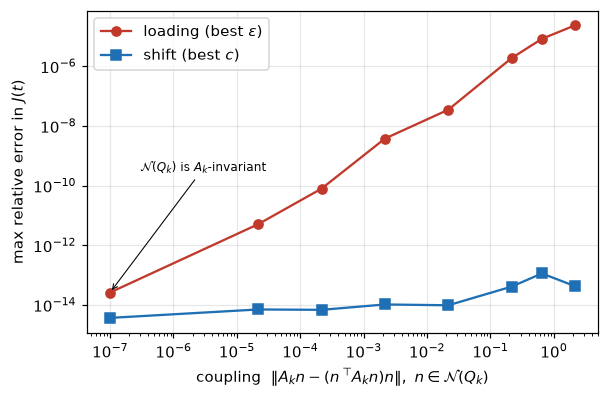

In [10]:
def coupled_problem(n, m, T, kappa, seed=0):
    r = np.random.default_rng(seed)
    A = []
    for _ in range(T):
        Ak = np.eye(n) + 0.15*r.normal(size=(n,n))
        Ak[:, -1] = 0.0; Ak[-1, -1] = 1.0
        Ak[:-1, -1] = kappa * r.normal(size=n-1)      # kappa = 0 -> invariant
        A.append(Ak)
    B = [np.vstack([r.normal(size=(n,m))[:-1], np.zeros((1,m))]) for _ in range(T)]
    R = _sym(r.normal(size=(m,m))); R = R @ R.T + np.eye(m)
    Q = []
    for _ in range(T):
        M = r.normal(size=(n-1,n-1))
        Qk = np.zeros((n,n)); Qk[:-1,:-1] = _sym(M @ M.T + np.eye(n-1))
        Q.append(_sym(Qk))                            # exactly singular on e_n
    Qf = np.zeros((n,n)); M = r.normal(size=(n-1,n-1))
    Qf[:-1,:-1] = _sym(M @ M.T + 5*np.eye(n-1))
    return A, B, Q, R, [_sym(Qf)]*T, r.normal(size=n)

kappas = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.3, 1.0]
n, m, Tc = 6, 3, 40
coup, L, S = [], [], []
for k in kappas:
    cl, ll, ss = [], [], []
    for s in range(4):
        A,B,Q,R,QT,z0 = coupled_problem(n,m,Tc,k,s)
        Jr = bruteforce(A,B,Q,R,z0,QT,Tc)
        lm = max(float(np.linalg.eigvalsh(_sym(M))[-1]) for M in Q+QT)
        ll.append(best_over(lambda e: relerr(hop(A,B,Q,R,z0,QT,Tc,eps=e), Jr),
                            10.0**np.arange(-14,-0.9,1.0))[0])
        ss.append(best_over(lambda c: relerr(shifted(A,B,Q,R,z0,QT,Tc,c), Jr),
                            lm*10.0**np.arange(-8,1.1,1.0))[0])
        nn = np.zeros(n); nn[-1] = 1.0
        cl.append(float(np.linalg.norm(A[0]@nn - (nn@A[0]@nn)*nn)))
    coup.append(np.median(cl)); L.append(np.median(ll)); S.append(np.median(ss))
coup, L, S = map(np.array, (coup, L, S))

print("TABLE III  Effect of dynamic coupling of an unpenalised direction\n")
print(f"  {'kappa':>8}{'coupling':>11}{'loading':>12}{'shift':>12}{'ratio':>11}")
print('  ' + '-'*54)
for k,c_,l_,s_ in zip(kappas, coup, L, S):
    print(f"  {k:>8.0e}{c_:>11.4f}{l_:>12.2e}{s_:>12.2e}{l_/max(s_,1e-300):>11.2e}")

fig, ax = plt.subplots(figsize=(6, 3.8))
x = np.where(coup > 0, coup, 1e-7)
ax.loglog(x, L, 'o-', color='#C0392B', label=r'loading (best $\varepsilon$)')
ax.loglog(x, S, 's-', color='#1F6FB4', label='shift (best $c$)')
ax.annotate(r'$\mathcal{N}(Q_k)$ is $A_k$-invariant', xy=(x[0], L[0]),
            xytext=(3e-7, 3e-10), fontsize=8,
            arrowprops=dict(arrowstyle='->', lw=0.7))
ax.set(xlabel=r'coupling  $\|A_k n-(n^\top\!A_k n)n\|,\ n\in\mathcal{N}(Q_k)$',
       ylabel='max relative error in $J(t)$')
ax.legend(loc='upper left'); plt.show()

## 6. Shift admissibility and the $c$ window (§V-G)

The admissibility condition **cannot** be reduced to "finitely many excluded
$c$". With $A=I$, $B=0$, $Q=0$ we get $\bar Q = cI$, $\widehat G = c^{-1}I$ and
hence $I - c\widehat G = 0$ for *every* $c$.

A sufficient condition is available in the other direction: if $Q_k \succ 0$
then $c\widehat G \to 0$ as $c \to 0$, so a small $c$ is always admissible.

In [11]:
print("Counterexample:  A = I,  B = 0,  Q = 0\n")
nn = 4
for c in [1e-6, 1e-3, 1.0, 1e3, 1e6]:
    Eh = np.linalg.inv(np.zeros((nn,nn)) + c*np.eye(nn))
    Gh = np.eye(nn) @ Eh @ np.eye(nn)                  # B = 0
    M = np.eye(nn) - c*Gh
    print(f"  c = {c:8.1e}   ||I - c*Ghat||_max = {np.abs(M).max():.3e}"
          f"   det = {np.linalg.det(M):.3e}")

print("\nOn controllable systems the matrix is near-degenerate but usable:\n")
print(f"  {'rank def':>9}{'c':>10}{'min|eig(I-cG)|':>17}{'rel err':>12}")
print('  ' + '-'*48)
for rk in (0, 1, 3):
    A,B,Q,R,QT,z0 = make_problem(6,3,30,rank_def=rk,seed=0)
    Jr = bruteforce(A,B,Q,R,z0,QT,30); Ri = np.linalg.inv(R)
    for c in (1e-2, 1.0, 1e2):
        worst = np.inf
        for k in range(30):
            Qbi = np.linalg.inv(_sym(Q[k]) + c*np.eye(6))
            Gh = _sym(A[k]@Qbi@A[k].T + B[k]@Ri@B[k].T)
            worst = min(worst, abs(np.linalg.eigvalsh(np.eye(6)-c*Gh)).min())
        try: e = relerr(shifted(A,B,Q,R,z0,QT,30,c), Jr)
        except Exception: e = np.nan
        print(f"  {rk:>9}{c:>10.1e}{worst:>17.3e}{e:>12.2e}")

Counterexample:  A = I,  B = 0,  Q = 0

  c =  1.0e-06   ||I - c*Ghat||_max = 0.000e+00   det = 0.000e+00
  c =  1.0e-03   ||I - c*Ghat||_max = 0.000e+00   det = 0.000e+00
  c =  1.0e+00   ||I - c*Ghat||_max = 0.000e+00   det = 0.000e+00
  c =  1.0e+03   ||I - c*Ghat||_max = 0.000e+00   det = 0.000e+00
  c =  1.0e+06   ||I - c*Ghat||_max = 0.000e+00   det = 0.000e+00

On controllable systems the matrix is near-degenerate but usable:

   rank def         c   min|eig(I-cG)|     rel err
  ------------------------------------------------
          0   1.0e-02        9.006e-01    8.94e-16
          0   1.0e+00        3.037e-02    1.07e-14
          0   1.0e+02        3.202e-03    5.35e-13
          1   1.0e-02        3.414e-03    4.79e-12
          1   1.0e+00        9.530e-03    4.78e-15
          1   1.0e+02        4.959e-03    1.59e-13
          3   1.0e-02        1.256e-03    1.05e-11
          3   1.0e+00        6.993e-03    4.35e-14
          3   1.0e+02        8.112e-03    1.53e-13


In [12]:
# The c window: accuracy against c/floor, and distance to the excluded set
A,B,Q,R,QT,z0 = make_problem(6,3,30,rank_def=1,seed=0)
Jr = bruteforce(A,B,Q,R,z0,QT,30); Ri = np.linalg.inv(R)
floor = choose_shift(Q, QT)
print(f"choose_shift -> c = {floor:.4g}\n")
print(f"  {'c/floor':>10}{'c':>12}{'rel err':>12}{'min|1-c*lam(Ghat)|':>21}")
print('  ' + '-'*55)
for mult in [1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4]:
    c = floor*mult; worst = np.inf
    for k in range(30):
        Qbi = np.linalg.inv(_sym(Q[k]) + c*np.eye(6))
        Gh = _sym(A[k]@Qbi@A[k].T + B[k]@Ri@B[k].T)
        worst = min(worst, float(np.abs(1 - c*np.linalg.eigvalsh(Gh)).min()))
    try: e = relerr(shifted(A,B,Q,R,z0,QT,30,c), Jr)
    except Exception: e = np.nan
    print(f"  {mult:>10.0e}{c:>12.3g}{e:>12.2e}{worst:>21.3e}")
print("\n  Two independent reasons not to take c large: cancellation in")
print("  P = Phat^-1 - cI, and the interconnection approaching ill-posedness.")

choose_shift -> c = 0.02552

     c/floor           c     rel err   min|1-c*lam(Ghat)|
  -------------------------------------------------------
       1e-02    0.000255    6.66e-09            8.208e-03
       1e-01     0.00255    1.66e-10            7.092e-03
       1e+00      0.0255    4.38e-13            4.549e-03
       1e+01       0.255    2.02e-14            2.307e-02
       1e+02        2.55    2.58e-15            1.026e-02
       1e+03        25.5    3.70e-14            1.552e-03
       1e+04         255    2.77e-12            1.007e-02

  Two independent reasons not to take c large: cancellation in
  P = Phat^-1 - cI, and the interconnection approaching ill-posedness.


## 7. §VI — $c$-independence as a selection diagnostic

$J_t$ is identical for every admissible $c$ in exact arithmetic, so
$\max_t|J_t(c_1)-J_t(c_2)|$ is a **computable** proxy for the error that needs
no reference. Diagonal loading has no analogue: varying $\varepsilon$ measures
perturbation of the problem, not roundoff.

In [13]:
def probe(A,B,Q,R,QT,z0,T, decades=np.arange(-4, 8.1, 1.0)):
    Jr = bruteforce(A,B,Q,R,z0,QT,T)
    cs = 10.0 ** decades
    J = {}
    for c in cs:
        try: J[c] = shifted(A,B,Q,R,z0,QT,T,c)
        except Exception: pass
    ks = sorted(J)
    true = {c: relerr(J[c], Jr) for c in ks}
    est = {}
    for i, c in enumerate(ks):
        nb = [ks[j] for j in (i-1, i+1) if 0 <= j < len(ks)]
        est[c] = max(relerr(J[c], J[d]) for d in nb)
    ct = min(ks, key=lambda c: true[c]); ce = min(ks, key=lambda c: est[c])
    return ks, true, est, ct, ce

for name, kw in [('n=6  T=30  rank def 1', dict(n=6,m=3,T=30, rank_def=1,seed=0)),
                 ('n=6  T=120 rank def 1', dict(n=6,m=3,T=120,rank_def=1,seed=0)),
                 ('n=6  T=30  q_scale=1e3',dict(n=6,m=3,T=30, rank_def=1,seed=0,
                                                q_scale=1e3))]:
    Tc = kw['T']; A,B,Q,R,QT,z0 = make_problem(**kw)
    ks, true, est, ct, ce = probe(A,B,Q,R,QT,z0,Tc)
    print(f"{name}")
    print(f"  true argmin c = {ct:.1e} (err {true[ct]:.2e})   "
          f"probe argmin c = {ce:.1e} (err {true[ce]:.2e})   "
          f"penalty {true[ce]/max(true[ct],1e-300):.2f}x")
print("\nThe estimator is conservative -- use it to SELECT c, not as an error bound.")

n=6  T=30  rank def 1
  true argmin c = 1.0e+00 (err 4.78e-15)   probe argmin c = 1.0e+00 (err 4.78e-15)   penalty 1.00x
n=6  T=120 rank def 1
  true argmin c = 1.0e+01 (err 2.75e-14)   probe argmin c = 1.0e+01 (err 2.75e-14)   penalty 1.00x
n=6  T=30  q_scale=1e3
  true argmin c = 1.0e+03 (err 1.80e-13)   probe argmin c = 1.0e+02 (err 4.15e-13)   penalty 2.31x

The estimator is conservative -- use it to SELECT c, not as an error bound.


## 8. §V-H — quadrotor-scale conditioning

$n_{\rm aug}=13$, $T_{\max}=160$. The point is that the error does **not** grow
with horizon length. A surrogate for the augmented quadrotor model is used here
so the notebook stays self-contained; the manuscript's numbers come from the
reference implementation's local quadratic model.

> **Surrogate, not the manuscript's model.** The numbers below come from a
> random LTV system at $n=13$, not from the quadrotor local quadratic model used
> in §V-H, so they will not match the manuscript. On this surrogate HOP is not
> stressed (its $Q_k$ are well conditioned) and can even beat the shift. Use it
> to confirm that neither method's error grows with horizon length; take the
> §V-H numbers from the reference implementation.

n_aug = 13, Tmax = 160, c = 0.0718

  method       max rel err   err at t=Tmax    T*
  ----------------------------------------------
  HOP             5.70e-15        4.77e-15     1
  shifted         1.98e-14        1.66e-14     1


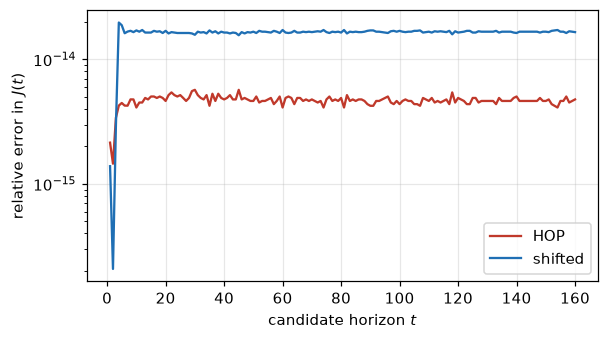

In [14]:
n, m, Tq = 13, 4, 160
A,B,Q,R,QT,z0 = make_problem(n,m,Tq,rank_def=0,seed=11,a_scale=0.05)
QT = [_sym(M) + 1e-13*np.eye(n) for M in QT]      # near rank-deficient terminal
Jr = bruteforce(A,B,Q,R,z0,QT,Tq)
Jh = hop(A,B,Q,R,z0,QT,Tq)
c  = choose_shift(Q,QT)
Js = shifted(A,B,Q,R,z0,QT,Tq,c)
eh, es = np.abs(Jh-Jr)/np.maximum(np.abs(Jr),1e-12), np.abs(Js-Jr)/np.maximum(np.abs(Jr),1e-12)
print(f"n_aug = {n}, Tmax = {Tq}, c = {c:.3g}\n")
print(f"  {'method':<10}{'max rel err':>14}{'err at t=Tmax':>16}{'T*':>6}")
print('  ' + '-'*46)
print(f"  {'HOP':<10}{eh.max():>14.2e}{eh[-1]:>16.2e}{int(np.argmin(Jh))+1:>6}")
print(f"  {'shifted':<10}{es.max():>14.2e}{es[-1]:>16.2e}{int(np.argmin(Js))+1:>6}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(np.arange(1,Tq+1), eh, color='#C0392B', label='HOP')
ax.semilogy(np.arange(1,Tq+1), es, color='#1F6FB4', label='shifted')
ax.set(xlabel='candidate horizon $t$', ylabel='relative error in $J(t)$')
ax.legend(); plt.show()

## 9. Table IV — runtime scaling (§V-I)

Brute force is $O(N^2n^3)$, the composed-map methods $O(Nn^3)$.

Two caveats that belong in the paper. Brute force is embarrassingly parallel
across $T$ while the composition sweep is a strict sequential chain, so much of
this gap closes on a multicore machine. And the shifted method measuring faster
than HOP is an implementation artefact, not an algorithmic advantage.

> **Surrogate timings.** Same caveat: this is a random LTV system at $n=13$, not
> the quadrotor model, so the ratios differ from Table IV. What reproduces is
> the scaling — brute force quadratic, both composed-map methods linear.

In [18]:
n, m = 13, 4
print(f"  {'Tmax':>6}{'BF (s)':>10}{'HOP (s)':>10}{'Shifted (s)':>13}"
      f"{'BF/HOP':>9}{'BF/Shift':>10}")
print('  ' + '-'*58)
for Tt in (20, 40, 80, 160):
    A,B,Q,R,QT,z0 = make_problem(n,m,Tt,rank_def=0,seed=11,a_scale=0.05)
    c = choose_shift(Q,QT)
    for fn in (lambda: bruteforce(A,B,Q,R,z0,QT,Tt),
               lambda: hop(A,B,Q,R,z0,QT,Tt),
               lambda: shifted(A,B,Q,R,z0,QT,Tt,c)):
        fn()                                        # warm up
    ts = []
    for fn in (lambda: bruteforce(A,B,Q,R,z0,QT,Tt),
               lambda: hop(A,B,Q,R,z0,QT,Tt),
               lambda: shifted(A,B,Q,R,z0,QT,Tt,c)):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter()-t0)
    tb, th, tsh = ts
    print(f"  {Tt:>6}{tb:>10.4f}{th:>10.4f}{tsh:>13.4f}"
          f"{tb/th:>9.1f}{tb/tsh:>10.1f}{th/tsh:>11.1f}")

    Tmax    BF (s)   HOP (s)  Shifted (s)   BF/HOP  BF/Shift
  ----------------------------------------------------------
      20    0.0040    0.0013       0.0020      3.0       2.0        0.7
      40    0.0138    0.0024       0.0037      5.7       3.7        0.7
      80    0.0539    0.0049       0.0074     11.1       7.3        0.7
     160    0.2152    0.0097       0.0147     22.2      14.6        0.7


### Reviewer question 2 — $W_k$ conditioning over long horizons with zero stage cost

$W_k = (E'_k + \bar G_{k-1})^{-1}$ is the one inversion inside the composition
loop. With $Q_k = 0$ the shifted chart is under maximum stress, so this is the
worst case for chaining.

In [19]:
n, m = 6, 3
print(f"  {'N':>6}{'max cond(W_k)':>16}{'max cond(I-cG)':>17}{'rel err vs BF':>16}")
print('  ' + '-'*55)
for N in (30, 60, 120, 240, 400):
    r = np.random.default_rng(3)
    A = [np.eye(n)+0.15*r.normal(size=(n,n)) for _ in range(N)]
    B = [r.normal(size=(n,m)) for _ in range(N)]
    R = _sym(r.normal(size=(m,m))); R = R @ R.T + np.eye(m)
    Q = [np.zeros((n,n)) for _ in range(N)]          # ZERO stage cost
    M = r.normal(size=(n,n)); Qf = _sym(M @ M.T + 5*np.eye(n))
    QT = [Qf]*N; z0 = r.normal(size=n)
    c = choose_shift(Q, QT); I = np.eye(n); Ri = np.linalg.inv(R)
    Ep = Fp = Gp = None; Eps, Fps, Gps = [], [], []; wG = 0.0
    for k in range(N):
        Et = np.linalg.inv(c*I); Ft = Et @ A[k].T
        Gt = _sym(A[k]@Et@A[k].T + B[k]@Ri@B[k].T)
        Mm = I - c*Gt; wG = max(wG, np.linalg.cond(Mm))
        Fk = np.linalg.solve(Mm.T, Ft.T).T; Gk = _sym(np.linalg.solve(Mm.T, Gt.T).T)
        Eps.append(_sym(Et + c*Fk@Ft.T)); Fps.append(Fk); Gps.append(Gk)
    Eb, Fb, Gb = [Eps[0]], [Fps[0]], [Gps[0]]; wW = 0.0
    for k in range(1, N):
        Wm = Eps[k] + Gb[-1]; wW = max(wW, np.linalg.cond(Wm))
        W = np.linalg.inv(Wm)
        Eb.append(_sym(Eb[-1]-Fb[-1]@W@Fb[-1].T)); Fb.append(Fb[-1]@W@Fps[k])
        Gb.append(_sym(Gps[k]-Fps[k].T@W@Fps[k]))
    Jb = bruteforce(A,B,Q,R,z0,QT,N); Js = np.zeros(N)
    for t in range(1, N+1):
        PT = np.linalg.inv(_sym(QT[t-1]) + c*I)
        P0h = _sym(Eb[t-1] - Fb[t-1]@np.linalg.inv(PT+Gb[t-1])@Fb[t-1].T)
        Js[t-1] = 0.5*z0@(_sym(np.linalg.inv(P0h)) - c*I)@z0
    print(f"  {N:>6}{wW:>16.2e}{wG:>17.2e}{relerr(Js,Jb):>16.2e}")
print("\n  Bounded, with no trend in N.")

       N   max cond(W_k)   max cond(I-cG)   rel err vs BF
  -------------------------------------------------------
      30        1.81e+03         1.65e+02        2.17e-11
      60        1.29e+04         1.33e+04        9.84e-10
     120        1.35e+04         1.15e+04        1.39e-10
     240        1.13e+05         3.42e+03        1.86e-11
     400        1.17e+04         2.09e+04        2.96e-09

  Bounded, with no trend in N.


## Notes for anyone extending this

1. **Never use a Cholesky-with-jitter wrapper** on $I - c\widehat G_k$ or on
   $Q_k$. Both are symmetric and indefinite in normal operation, and such a
   wrapper silently returns the inverse of a materially different matrix.
2. **`np.linalg.svd` returns singular values in descending order**, so `s[-1]`
   is the smallest. Zeroing `s[0]` removes the dominant mode instead.
3. **Recompute the reference after any edit to `Q`.** Comparing a solver run on
   one cost against a reference computed from another compares two different
   problems.
4. **HOP requires $Q_k$ *invertible*, not positive definite.** An indefinite but
   nonsingular $Q_k$ is handled correctly once a Cholesky-based inverse is
   replaced by LU. The genuine gap is singularity, and the case for the shift
   over loading rests on §V-D and §V-E rather than on indefiniteness alone.